In [1]:
import os
import warnings

import agama
import astropy
import cmasher as cmr
import gc_utils
import gizmo_analysis as gizmo
import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
import utilities as ut
from matplotlib.animation import PillowWriter
from matplotlib.colors import LogNorm, Normalize
from matplotlib.gridspec import GridSpec
from mpl_toolkits.axes_grid1 import make_axes_locatable
from scipy import stats
from scipy.interpolate import griddata, interp1d
from scipy.ndimage import gaussian_filter
from scipy.optimize import curve_fit, minimize
from scipy.signal import find_peaks
from scipy.stats import gaussian_kde, lognorm, norm
from sklearn.svm import SVC, LinearSVC

agama.setUnits(mass=1, length=1, velocity=1)
units = agama.getUnits()

# plt.rc("font", family="Nimbus Roman")
plt.rc("font", family="Nimbus Roman No9 L")

SMALL_SIZE = 10
MEDIUM_SIZE = 10
BIGGER_SIZE = 10

plt.rc("font", size=SMALL_SIZE)  # controls default text sizes
plt.rc("axes", titlesize=SMALL_SIZE)  # fontsize of the axes title
plt.rc("axes", labelsize=MEDIUM_SIZE)  # fontsize of the x and y labels
plt.rc("xtick", labelsize=SMALL_SIZE)  # fontsize of the tick labels
plt.rc("ytick", labelsize=SMALL_SIZE)  # fontsize of the tick labels
plt.rc("legend", fontsize=SMALL_SIZE)  # legend fontsize
plt.rc("figure", titlesize=BIGGER_SIZE)  # fontsize of the figure title

In [2]:
sim_lst = ["m12b", "m12c", "m12f", "m12i", "m12m"]
sim_cmap = plt.get_cmap("tab10")
sim_colors = [sim_cmap(i) for i in np.linspace(0, 1, len(sim_lst))]

sim_dir = "/Users/z5114326/Documents/simulations/"

snap = 600

public_snapshot_file = sim_dir + "snapshot_times_public.txt"
pub_data = pd.read_table(public_snapshot_file, comment="#", header=None, sep=r"\s+")
pub_data.columns = [
    "index",
    "scale_factor",
    "redshift",
    "time_Gyr",
    "lookback_time_Gyr",
    "time_width_Myr",
]
snap_lst = np.array(pub_data["index"])
timez0 = np.array(pub_data["time_Gyr"])[-1]

In [3]:
sim_dict = {}
for sim in sim_lst:
    ghost_file = f"{sim_dir}{sim}/{sim}_ghosts.hdf5"
    ghost_data = h5py.File(ghost_file, "r")

    sim_dict[sim] = {}
    for it_id in ghost_data.keys():
        src_dat = ghost_data[it_id]["source"]

        amsk = src_dat["grpid"][()] == 0
        grpid = src_dat["grpid"][()]
        samsk = src_dat["sa_flag"][()]

        m_tfo = 10 ** src_dat["logm_tfor"][()]
        m_tfo_ev = 0.55 * (10 ** src_dat["logm_tfor"][()])

        m_tz0_log = src_dat["logm_tz0"][()]
        m_tz0 = np.array([10**x if x != -1 else 0 for x in m_tz0_log])

        tfor = src_dat["tfor"][()]
        tdis = src_dat["tdis"][()]
        tacc = src_dat["tacc"][()]

        r_bir = src_dat["halo.r.birth"][()]

        age = timez0 - tfor
        age_p = np.array([x - y if x != -1 else timez0 - y for x, y in zip(tdis, tfor)])

        t_tz0 = src_dat["torb_600"][()]
        s_tz0 = np.array(src_dat["s_flag"][()], dtype=bool)

        ml = m_tfo_ev - m_tz0
        ml_rate = (m_tfo_ev - m_tz0) / age_p

        sim_dict[sim][it_id] = {}
        sim_dict[sim][it_id]["m_tfo"] = m_tfo
        sim_dict[sim][it_id]["m_tfo_ev"] = m_tfo_ev
        sim_dict[sim][it_id]["m_tz0"] = m_tz0
        sim_dict[sim][it_id]["tfor"] = tfor
        sim_dict[sim][it_id]["tdis"] = tdis
        sim_dict[sim][it_id]["tacc"] = tacc
        sim_dict[sim][it_id]["age"] = age
        sim_dict[sim][it_id]["age_p"] = age_p
        sim_dict[sim][it_id]["t_tz0"] = t_tz0
        sim_dict[sim][it_id]["s_tz0"] = s_tz0
        sim_dict[sim][it_id]["ml"] = ml
        sim_dict[sim][it_id]["ml_rate"] = ml_rate
        sim_dict[sim][it_id]["acc"] = amsk
        sim_dict[sim][it_id]["grp"] = grpid
        sim_dict[sim][it_id]["samsk"] = samsk
        sim_dict[sim][it_id]["r_bir"] = r_bir

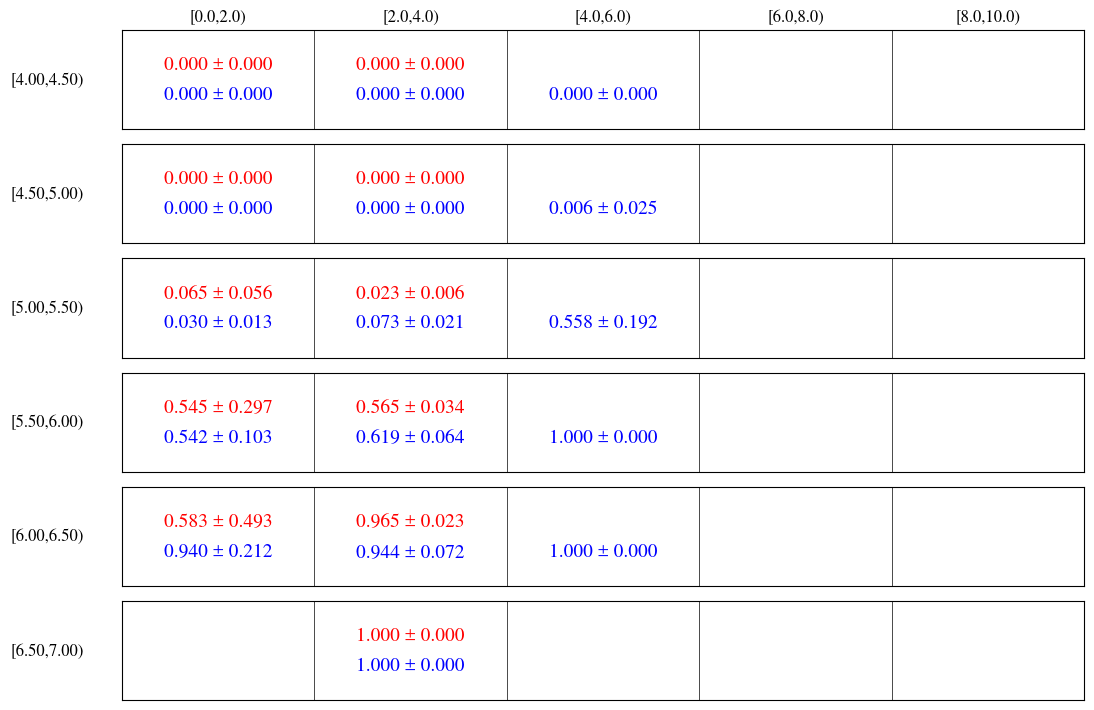

In [4]:
sim = "m12m"

tfor_bins = np.arange(0, 12, 2)
mfor_bins = 10 ** np.arange(4, 7.5, 0.5)

data_arr = np.empty(shape=(len(mfor_bins) - 1, len(tfor_bins) - 1), dtype=object)
for i, j in np.ndindex(data_arr.shape):
    data_arr[i, j] = {"in-situ": None, "ex-situ": None}

for i, j in np.ndindex(data_arr.shape):
    mfor_min = mfor_bins[i]
    mfor_max = mfor_bins[i + 1]

    tfor_min = tfor_bins[j]
    tfor_max = tfor_bins[j + 1]

    in_hld_lst = []
    ex_hld_lst = []
    for it_id in sim_dict[sim].keys():
        amsk = sim_dict[sim][it_id]["acc"][()]
        smsk = sim_dict[sim][it_id]["s_tz0"][()]

        mfor = sim_dict[sim][it_id]["m_tfo"][()]
        tfor = sim_dict[sim][it_id]["tfor"][()]

        mmsk = (mfor_min <= mfor) & (mfor < mfor_max)
        tmsk = (tfor_min <= tfor) & (tfor < tfor_max)

        if np.sum(amsk & mmsk & tmsk) == 0:
            in_hld_lst.append(np.nan)
        else:
            in_hld_lst.append(np.sum(amsk & smsk & mmsk & tmsk) / np.sum(amsk & mmsk & tmsk))

        if np.sum(~amsk & mmsk & tmsk) == 0:
            ex_hld_lst.append(np.nan)
        else:
            ex_hld_lst.append(np.sum(~amsk & smsk & mmsk & tmsk) / np.sum(~amsk & mmsk & tmsk))

    if np.all(np.isnan(in_hld_lst)):
        in_avg = np.nan
        in_std = np.nan
    else:
        in_avg = np.nanmean(in_hld_lst)
        in_std = np.nanstd(in_hld_lst)

    if np.all(np.isnan(ex_hld_lst)):
        ex_avg = np.nan
        ex_std = np.nan
    else:
        ex_avg = np.nanmean(ex_hld_lst)
        ex_std = np.nanstd(ex_hld_lst)

    data_arr[i, j]["in-situ"] = {"avg": in_avg, "std": in_std}
    data_arr[i, j]["ex-situ"] = {"avg": ex_avg, "std": ex_std}

n_m = len(mfor_bins) - 1
n_t = len(tfor_bins) - 1

fig, axs = plt.subplots(nrows=n_m, ncols=1, figsize=(2.2 * n_t, 1.2 * n_m), sharex=False)

if n_m == 1:
    axs = [axs]

for i in range(n_m):
    ax = axs[i]
    ax.set_xlim(0, n_t)
    ax.set_ylim(0, 1)

    ax.set_xticks([])
    ax.set_yticks([])

    # ---- Mass bin label (left side) ----
    mmin = np.log10(mfor_bins[i])
    mmax = np.log10(mfor_bins[i + 1])

    ax.text(-0.2, 0.5, f"[{mmin:.2f},{mmax:.2f})", va="center", ha="right", fontsize=12)
    # ax.text(-0.2, 0.5, f"{mmin:.2f} $\leq$ log$_{10}$ $M_\star$ / M_\odot < {mmax:.2f}", va="center", ha="right", fontsize=10, rotate = 90)

    for j in range(n_t):
        avg_in = data_arr[i, j]["in-situ"]["avg"]
        std_in = data_arr[i, j]["in-situ"]["std"]

        avg_ex = data_arr[i, j]["ex-situ"]["avg"]
        std_ex = data_arr[i, j]["ex-situ"]["std"]

        x = j + 0.5

        # ---- In-situ (top, red) ----
        if not np.isnan(avg_in):
            ax.text(
                x, 0.65, f"{avg_in:.3f} ± {std_in:.3f}", ha="center", va="center", color="red", fontsize=14
            )

        # ---- Ex-situ (bottom, blue) ----
        if not np.isnan(avg_ex):
            ax.text(
                x, 0.35, f"{avg_ex:.3f} ± {std_ex:.3f}", ha="center", va="center", color="blue", fontsize=14
            )

    # vertical separators
    for xline in range(n_t + 1):
        ax.axvline(xline, color="black", lw=0.5)

    ax.axhline(0, color="black", lw=0.5)
    ax.axhline(1, color="black", lw=0.5)

# ---- Column labels on top row ----
top_ax = axs[0]

for j in range(n_t):
    tmin = tfor_bins[j]
    tmax = tfor_bins[j + 1]

    top_ax.text(j + 0.5, 1.05, f"[{tmin:.1f},{tmax:.1f})", ha="center", va="bottom", fontsize=12)

plt.tight_layout()
plt.show()

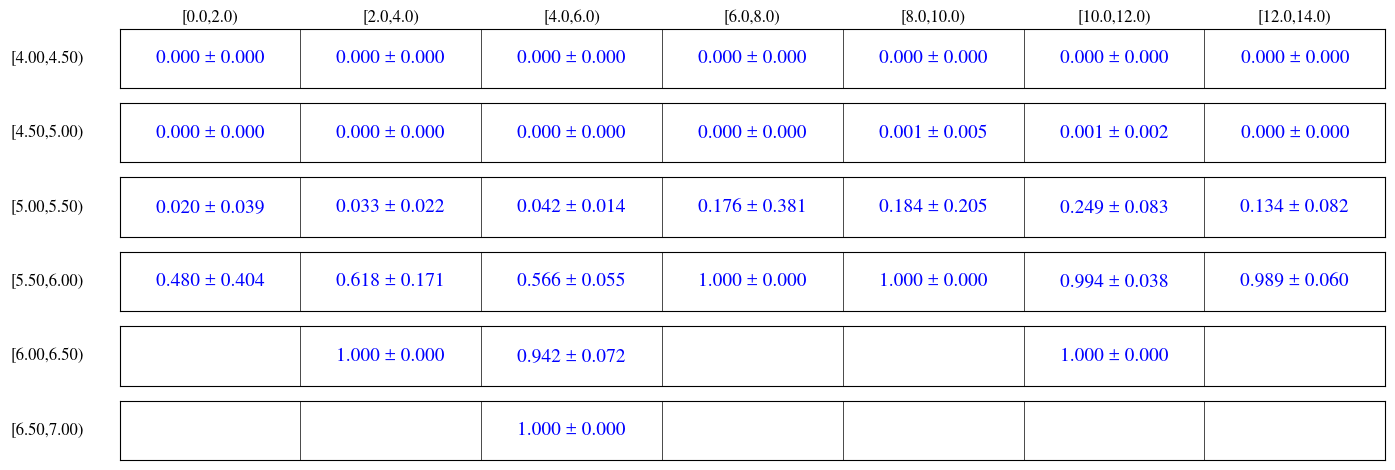

In [5]:
sim = "m12m"

tacc_bins = np.arange(0, 16, 2)
mfor_bins = 10 ** np.arange(4, 7.5, 0.5)

data_arr = np.empty(shape=(len(mfor_bins) - 1, len(tacc_bins) - 1), dtype=object)
for i, j in np.ndindex(data_arr.shape):
    data_arr[i, j] = {"ex-situ": None}

for i, j in np.ndindex(data_arr.shape):
    mfor_min = mfor_bins[i]
    mfor_max = mfor_bins[i + 1]

    tacc_min = tacc_bins[j]
    tacc_max = tacc_bins[j + 1]

    ex_hld_lst = []
    for it_id in sim_dict[sim].keys():
        amsk = sim_dict[sim][it_id]["acc"][()]
        smsk = sim_dict[sim][it_id]["s_tz0"][()]

        mfor = sim_dict[sim][it_id]["m_tfo"][()]
        tacc = sim_dict[sim][it_id]["tacc"][()]

        mmsk = (mfor_min <= mfor) & (mfor < mfor_max)
        tmsk = (tacc_min <= tacc) & (tacc < tacc_max)

        if np.sum(~amsk & mmsk & tmsk) == 0:
            ex_hld_lst.append(np.nan)
        else:
            ex_hld_lst.append(np.sum(~amsk & smsk & mmsk & tmsk) / np.sum(~amsk & mmsk & tmsk))

    if np.all(np.isnan(ex_hld_lst)):
        ex_avg = np.nan
        ex_std = np.nan
    else:
        ex_avg = np.nanmean(ex_hld_lst)
        ex_std = np.nanstd(ex_hld_lst)

    data_arr[i, j]["in-situ"] = {"avg": in_avg, "std": in_std}
    data_arr[i, j]["ex-situ"] = {"avg": ex_avg, "std": ex_std}

n_m = len(mfor_bins) - 1
n_t = len(tacc_bins) - 1

fig, axs = plt.subplots(nrows=n_m, ncols=1, figsize=(2 * n_t, 0.8 * n_m), sharex=False)

if n_m == 1:
    axs = [axs]

for i in range(n_m):
    ax = axs[i]
    ax.set_xlim(0, n_t)
    ax.set_ylim(0, 1)

    ax.set_xticks([])
    ax.set_yticks([])

    # ---- Mass bin label (left side) ----
    mmin = np.log10(mfor_bins[i])
    mmax = np.log10(mfor_bins[i + 1])

    ax.text(-0.2, 0.5, f"[{mmin:.2f},{mmax:.2f})", va="center", ha="right", fontsize=12)
    # ax.text(-0.2, 0.5, f"{mmin:.2f} $\leq$ log$_{10}$ $M_\star$ / M_\odot < {mmax:.2f}", va="center", ha="right", fontsize=10, rotate = 90)

    for j in range(n_t):
        avg_ex = data_arr[i, j]["ex-situ"]["avg"]
        std_ex = data_arr[i, j]["ex-situ"]["std"]

        x = j + 0.5

        # ---- Ex-situ (bottom, blue) ----
        if not np.isnan(avg_ex):
            ax.text(
                x, 0.5, f"{avg_ex:.3f} ± {std_ex:.3f}", ha="center", va="center", color="blue", fontsize=14
            )

    # vertical separators
    for xline in range(n_t + 1):
        ax.axvline(xline, color="black", lw=0.5)

    ax.axhline(0, color="black", lw=0.5)
    ax.axhline(1, color="black", lw=0.5)

# ---- Column labels on top row ----
top_ax = axs[0]

for j in range(n_t):
    tmin = tacc_bins[j]
    tmax = tacc_bins[j + 1]

    top_ax.text(j + 0.5, 1.05, f"[{tmin:.1f},{tmax:.1f})", ha="center", va="bottom", fontsize=12)

plt.tight_layout()
plt.show()

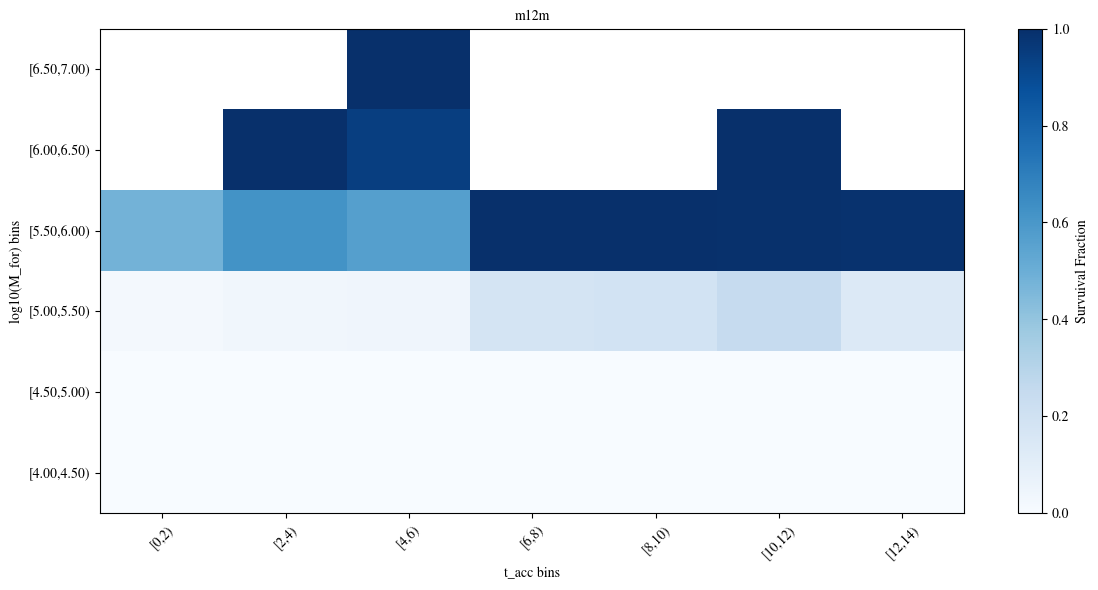

In [6]:
sim = "m12m"

tacc_bins = np.arange(0, 16, 2)
mfor_bins = 10 ** np.arange(4, 7.5, 0.5)

data_arr = np.empty(shape=(len(mfor_bins) - 1, len(tacc_bins) - 1), dtype=object)
for i, j in np.ndindex(data_arr.shape):
    data_arr[i, j] = {"ex-situ": None}

# Compute ex-situ fractions
for i, j in np.ndindex(data_arr.shape):
    mfor_min = mfor_bins[i]
    mfor_max = mfor_bins[i + 1]

    tacc_min = tacc_bins[j]
    tacc_max = tacc_bins[j + 1]

    ex_hld_lst = []
    for it_id in sim_dict[sim].keys():
        amsk = sim_dict[sim][it_id]["acc"][()]
        smsk = sim_dict[sim][it_id]["s_tz0"][()]

        mfor = sim_dict[sim][it_id]["m_tfo"][()]
        tacc = sim_dict[sim][it_id]["tacc"][()]

        mmsk = (mfor_min <= mfor) & (mfor < mfor_max)
        tmsk = (tacc_min <= tacc) & (tacc < tacc_max)

        if np.sum(~amsk & mmsk & tmsk) == 0:
            ex_hld_lst.append(np.nan)
        else:
            ex_hld_lst.append(np.sum(~amsk & smsk & mmsk & tmsk) / np.sum(~amsk & mmsk & tmsk))

    if np.all(np.isnan(ex_hld_lst)):
        ex_avg = np.nan
    else:
        ex_avg = np.nanmean(ex_hld_lst)

    data_arr[i, j]["ex-situ"] = {"avg": ex_avg}

# Build 2D array for imshow
frac_arr = np.array(
    [[data_arr[i, j]["ex-situ"]["avg"] for j in range(len(tacc_bins) - 1)] for i in range(len(mfor_bins) - 1)]
)

# ---- Plotting ----
fig, ax = plt.subplots(figsize=(12, 6))

im = ax.imshow(frac_arr, origin="lower", aspect="auto", cmap="Blues", vmin=0, vmax=1)

# ---- Labels ----
ax.set_xticks(np.arange(len(tacc_bins) - 1))
ax.set_xticklabels([f"[{tacc_bins[j]},{tacc_bins[j + 1]})" for j in range(len(tacc_bins) - 1)], rotation=45)
ax.set_yticks(np.arange(len(mfor_bins) - 1))
ax.set_yticklabels(
    [f"[{np.log10(mfor_bins[i]):.2f},{np.log10(mfor_bins[i + 1]):.2f})" for i in range(len(mfor_bins) - 1)]
)

ax.set_xlabel("t_acc bins")
ax.set_ylabel("log10(M_for) bins")
ax.set_title(f"{sim}")

# ---- Colorbar ----
cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Survuival Fraction")

plt.tight_layout()
plt.show()

In [7]:
sim = "m12f"
it_id = "it001"

ghost_file = f"{sim_dir}{sim}/{sim}_ghosts.hdf5"
ghost_data = h5py.File(ghost_file, "r")

src_dat = ghost_data[it_id]["source"]
amsk = src_dat["grpid"][()] == 0
smsk = src_dat["s_flag"][()].astype(bool)

gcids = src_dat["gcid"][~amsk & smsk]
taccs = src_dat["tacc"][~amsk & smsk]
tfors = src_dat["tfor"][~amsk & smsk]
mtfors = 10 ** src_dat["logm_tfor"][~amsk & smsk]
mtforevs = 0.55 * mtfors

data_dict = {
    gcid: {"t_snp": [], "m_snp": [], "tacc": tacc, "tfor": tfor, "mtfor": mtfor, "mtforev": mtforev}
    for gcid, tacc, tfor, mtfor, mtforev in zip(gcids, taccs, tfors, mtfors, mtforevs)
}

for snap in snap_lst:
    snap_id = gc_utils.snapshot_name(snap)
    time = float(pub_data[pub_data["index"] == snap]["time_Gyr"].values[0])

    snp_dat = ghost_data[it_id]["snapshots"][snap_id]
    gcids_snp = snp_dat["gcid"][()]
    mass_snp = 10 ** snp_dat["logm"][()]

    gcid_msk = np.isin(gcids_snp, gcids)
    gc_snp_dict = {gcids_snp[idx]: idx for idx in np.nonzero(gcid_msk)[0]}

    for gcid in gcids:
        if gcid not in gcids_snp:
            data_dict[gcid]["m_snp"].append(np.nan)
            data_dict[gcid]["t_snp"].append(np.nan)
            continue
        gcidx = gc_snp_dict[gcid]
        data_dict[gcid]["m_snp"].append(mass_snp[gcidx])
        data_dict[gcid]["t_snp"].append(time)

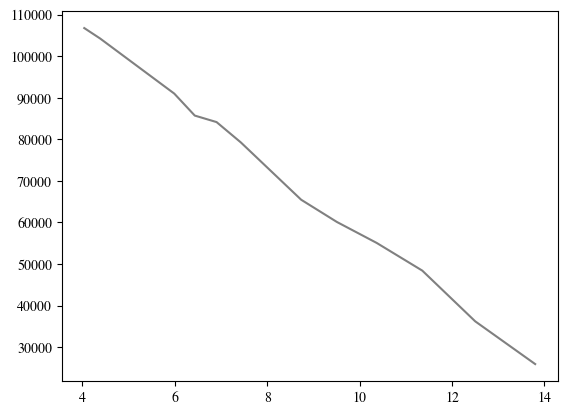

In [8]:
masses = np.array(data_dict[gcid]["m_snp"])[~np.isnan(data_dict[gcid]["m_snp"])]
masses = np.insert(masses, 0, data_dict[gcid]["mtforev"])  # post instantaneous mass evolution

times = np.array(data_dict[gcid]["t_snp"])[~np.isnan(data_dict[gcid]["t_snp"])]
times = np.insert(times, 0, data_dict[gcid]["tfor"])

# remove near-duplicate times (small dt can cause unrealistic spikes)
dt = np.diff(times)
# mask = np.insert(dt > 0.01, 0, True)  # keep first point, remove very tiny intervals
mask = np.append(dt > 0.01, True)
times_clean = times[mask]
masses_clean = masses[mask]

massloss = np.gradient(masses_clean, times_clean)  # dM/dt
massloss_frac = -massloss / masses_clean  # fractional rate

times_acc = times_clean - np.array(data_dict[gcid]["tacc"])

plt.plot(times_clean, masses_clean, c="grey")

# plt.axvline(0, c="r")
# # plt.ylim(0, -5000)
# plt.yscale("log")

##############################

# dtacc = 0.5  # Gyr

# masses = np.array(data_dict[gcid]["m_snp"])[~np.isnan(data_dict[gcid]["m_snp"])]
# masses = np.insert(masses, 0, data_dict[gcid]["mtforev"])  # post instantaneous mass evolution

# times = np.array(data_dict[gcid]["t_snp"])[~np.isnan(data_dict[gcid]["t_snp"])]
# times = np.insert(times, 0, data_dict[gcid]["tfor"])

# # remove near-duplicate times (small dt can cause unrealistic spikes in gradient)
# dt = np.diff(times)
# mask = np.insert(dt > 0.01, 0, True)  # keep first point, remove very tiny intervals
# times_clean = times[mask]
# masses_clean = masses[mask]

# massloss = np.gradient(masses_clean, times_clean)  # dM/dt
# massloss_frac = -massloss / masses_clean  # fractional rate

# f_cubic = interp1d(times, masses, kind="cubic")

# tacc = data_dict[gcid]["tacc"]

# plt.plot(times, masses)
# plt.scatter(tacc, f_cubic(tacc))

# m_tforev = data_dict[gcid]["mtforev"]
# m_tacc = f_cubic(data_dict[gcid]["tacc"])
# m_tz0 = masses[-1]

In [9]:
mass_dict = {sim: {it_id: {} for it_id in sim_dict[sim].keys()} for sim in sim_lst}

for sim in mass_dict.keys():
    ghost_file = f"{sim_dir}{sim}/{sim}_ghosts.hdf5"
    ghost_data = h5py.File(ghost_file, "r")

    for it_id in sim_dict[sim].keys():
        src_dat = ghost_data[it_id]["source"]
        amsk = src_dat["grpid"][()] == 0
        smsk = src_dat["s_flag"][()].astype(bool)

        gcids = src_dat["gcid"][~amsk & smsk]
        taccs = src_dat["tacc"][~amsk & smsk]
        tfors = src_dat["tfor"][~amsk & smsk]
        mtfors = 10 ** src_dat["logm_tfor"][~amsk & smsk]
        mtforevs = 0.55 * mtfors

        samsks = src_dat["sa_flag"][~amsk & smsk].astype(bool)

        data_dict = {
            gcid: {
                "t_snp": [],
                "m_snp": [],
                "tacc": tacc,
                "tfor": tfor,
                "mtfor": mtfor,
                "mtforev": mtforev,
                "samsk": samsk,
            }
            for gcid, tacc, tfor, mtfor, mtforev, samsk in zip(gcids, taccs, tfors, mtfors, mtforevs, samsks)
        }

        for snap in snap_lst:
            snap_id = gc_utils.snapshot_name(snap)
            time = float(pub_data[pub_data["index"] == snap]["time_Gyr"].values[0])

            snp_dat = ghost_data[it_id]["snapshots"][snap_id]
            gcids_snp = snp_dat["gcid"][()]
            mass_snp = 10 ** snp_dat["logm"][()]

            gcid_msk = np.isin(gcids_snp, gcids)
            gc_snp_dict = {gcids_snp[idx]: idx for idx in np.nonzero(gcid_msk)[0]}

            for gcid in gcids:
                if gcid not in gcids_snp:
                    data_dict[gcid]["m_snp"].append(np.nan)
                    data_dict[gcid]["t_snp"].append(np.nan)
                    continue
                gcidx = gc_snp_dict[gcid]
                data_dict[gcid]["m_snp"].append(mass_snp[gcidx])
                data_dict[gcid]["t_snp"].append(time)

        mass_dict[sim][it_id] = data_dict

In [10]:
plot_dict = {sim: {it_id: {} for it_id in mass_dict[sim].keys()} for sim in sim_lst}

for sim in sim_lst:
    for it_id in mass_dict[sim].keys():
        f_loss_rate_pre = np.array([])
        f_loss_rate_pos = np.array([])
        mfor = np.array([])
        tacc = np.array([])
        tfor = np.array([])
        samsk = np.array([])

        for gcid in mass_dict[sim][it_id].keys():
            masses = np.array(mass_dict[sim][it_id][gcid]["m_snp"])[
                ~np.isnan(mass_dict[sim][it_id][gcid]["m_snp"])
            ]
            masses = np.insert(
                masses, 0, mass_dict[sim][it_id][gcid]["mtforev"]
            )  # post instantaneous mass evolution

            times = np.array(mass_dict[sim][it_id][gcid]["t_snp"])[
                ~np.isnan(mass_dict[sim][it_id][gcid]["t_snp"])
            ]
            times = np.insert(times, 0, mass_dict[sim][it_id][gcid]["tfor"])

            dt = np.diff(times)
            # mask = np.insert(dt > 0.01, 0, True)  # keep first point, remove very tiny intervals
            mask = np.append(dt > 0.01, True)  # keep last point, remove very tiny intervals

            times_clean = times[mask]
            masses_clean = masses[mask]

            f_cubic = interp1d(times_clean, masses_clean, kind="cubic")

            tfor_i = mass_dict[sim][it_id][gcid]["tfor"]
            tacc_i = mass_dict[sim][it_id][gcid]["tacc"]
            tz0 = times[-1]

            m_tforev = mass_dict[sim][it_id][gcid]["mtforev"]
            m_tacc = f_cubic(mass_dict[sim][it_id][gcid]["tacc"])
            m_tz0 = masses[-1]

            f_loss_pre_i = (m_tforev - m_tacc) / m_tforev
            f_loss_pos_i = (m_tacc - m_tz0) / m_tacc

            f_loss_rate_pre_i = np.array([f_loss_pre_i / (tacc_i - tfor_i)])
            f_loss_rate_pos_i = np.array([f_loss_pos_i / (tz0 - tacc_i)])
            mfor_i = np.array([mass_dict[sim][it_id][gcid]["mtfor"]])

            tacc_i = np.array([mass_dict[sim][it_id][gcid]["tacc"]])
            tfor_i = np.array([mass_dict[sim][it_id][gcid]["tfor"]])
            samsk_i = np.array([mass_dict[sim][it_id][gcid]["samsk"]])

            f_loss_rate_pre = np.concatenate((f_loss_rate_pre, f_loss_rate_pre_i))
            f_loss_rate_pos = np.concatenate((f_loss_rate_pos, f_loss_rate_pos_i))
            mfor = np.concatenate((mfor, mfor_i))

            tacc = np.concatenate((tacc, tacc_i))
            tfor = np.concatenate((tfor, tfor_i))

            samsk = np.concatenate((samsk, samsk_i))

        plot_dict[sim][it_id]["f_loss_rate_pre"] = f_loss_rate_pre
        plot_dict[sim][it_id]["f_loss_rate_pos"] = f_loss_rate_pos
        plot_dict[sim][it_id]["mfor"] = mfor
        plot_dict[sim][it_id]["tacc"] = tacc
        plot_dict[sim][it_id]["tfor"] = tfor
        plot_dict[sim][it_id]["samsk"] = samsk

In [11]:
plot_dict = {sim: {it_id: {} for it_id in mass_dict[sim].keys()} for sim in sim_lst}

for sim in sim_lst:
    for it_id in mass_dict[sim].keys():
        gamma_pre = np.array([])
        gamma_post = np.array([])
        mfor_arr = np.array([])
        tacc_arr = np.array([])
        tfor_arr = np.array([])
        samsk = np.array([])

        for gcid in mass_dict[sim][it_id].keys():
            # extract masses and times, remove NaNs
            masses = np.array(mass_dict[sim][it_id][gcid]["m_snp"])
            times = np.array(mass_dict[sim][it_id][gcid]["t_snp"])
            valid = ~np.isnan(masses) & ~np.isnan(times)
            masses = masses[valid]
            times = times[valid]

            # add formation mass/time at start
            masses = np.insert(masses, 0, mass_dict[sim][it_id][gcid]["mtforev"])
            times = np.insert(times, 0, mass_dict[sim][it_id][gcid]["tfor"])

            # remove tiny dt intervals, keep last point
            dt = np.diff(times)
            mask = np.append(dt > 0.01, True)
            masses_clean = masses[mask]
            times_clean = times[mask]

            # linear interpolation (safer than cubic)
            f_interp = interp1d(times_clean, masses_clean, kind="linear", fill_value="extrapolate")

            # key times
            tfor_i = mass_dict[sim][it_id][gcid]["tfor"]
            tacc_i = mass_dict[sim][it_id][gcid]["tacc"]
            tz0 = times[-1]

            # interpolated masses at key times
            m_tforev = mass_dict[sim][it_id][gcid]["mtforev"]
            m_tacc = f_interp(tacc_i)
            m_tz0 = masses[-1]

            samsk_i = np.array([mass_dict[sim][it_id][gcid]["samsk"]])

            # skip invalid cases
            if tacc_i <= tfor_i or tz0 <= tacc_i:
                continue
            if m_tforev <= 0 or m_tacc <= 0 or m_tz0 <= 0:
                continue

            # log fractional mass-loss rates (per Gyr)
            gamma_pre_i = np.log(m_tforev / m_tacc) / (tacc_i - tfor_i)
            gamma_post_i = np.log(m_tacc / m_tz0) / (tz0 - tacc_i)

            # GC formation mass
            mfor_i = mass_dict[sim][it_id][gcid]["mtfor"]

            # append to arrays
            gamma_pre = np.append(gamma_pre, gamma_pre_i)
            gamma_post = np.append(gamma_post, gamma_post_i)
            mfor_arr = np.append(mfor_arr, mfor_i)
            tacc_arr = np.append(tacc_arr, tacc_i)
            tfor_arr = np.append(tfor_arr, tfor_i)
            samsk = np.append(samsk, samsk_i)

        # store results in plot_dict
        plot_dict[sim][it_id]["gamma_pre"] = gamma_pre
        plot_dict[sim][it_id]["gamma_post"] = gamma_post
        plot_dict[sim][it_id]["mfor"] = mfor_arr
        plot_dict[sim][it_id]["tacc"] = tacc_arr
        plot_dict[sim][it_id]["tfor"] = tfor_arr
        plot_dict[sim][it_id]["samsk"] = samsk

In [12]:
len(plot_dict[sim][it_id]["samsk"])

72

In [13]:
len(plot_dict[sim][it_id]["gamma_pre"])

72

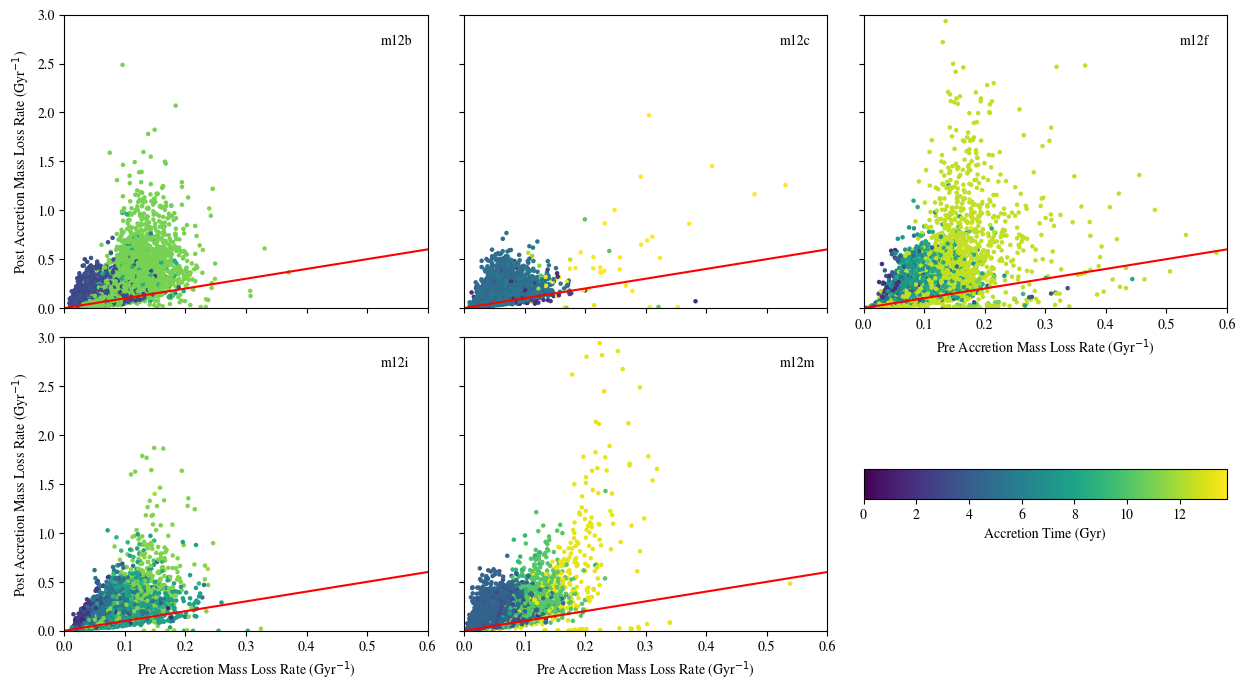

In [14]:
vmin = 0
vmax = tz0

fig, axs = plt.subplots(2, 3, figsize=(15, 8), sharex=True, sharey=True)
plt.subplots_adjust(hspace=0.1, wspace=0.1)

axs_flat = axs.flatten()
sc = None

for k, sim in enumerate(sim_lst):
    ax = axs_flat[k]

    for it_id in plot_dict[sim].keys():
        msk = plot_dict[sim][it_id]["samsk"].astype(bool)
        sc = ax.scatter(
            # plot_dict[sim][it_id]["f_loss_rate_pre"],
            # plot_dict[sim][it_id]["f_loss_rate_pos"],
            plot_dict[sim][it_id]["gamma_pre"][msk],
            plot_dict[sim][it_id]["gamma_post"][msk],
            c=plot_dict[sim][it_id]["tacc"][msk],
            s=5,
            vmin=vmin,
            vmax=vmax,
        )

    ax.plot([0, 1], [0, 1], c="r")
    ax.set_xlim([0, 0.6])
    ax.set_ylim([0, 3])

    ax.text(
        0.87,
        0.90,
        sim,
        transform=ax.transAxes,
        # fontsize=12,
        color="k",
        ha="left",
        bbox=dict(
            facecolor="white",
            edgecolor="white",
        ),
    )

    if k > 1:
        ax.set_xlabel(r"Pre Accretion Mass Loss Rate (Gyr$^{-1}$)")

    if (k == 0) or (k == 3):
        ax.set_ylabel(r"Post Accretion Mass Loss Rate (Gyr$^{-1}$)")

axs[0, 2].tick_params(labelbottom=True)

# ---- Empty subplot becomes colorbar container ----
empty_ax = axs[1, 2]
empty_ax.axis("off")  # hide frame & ticks

# ---- Adjustable height parameter ----
cbar_height = 0.1  # change this (0–1)

# Center vertically
bottom = 0.5 - cbar_height / 2

# Full width, adjustable height
cax = empty_ax.inset_axes([0, bottom, 1, cbar_height])

cbar = fig.colorbar(sc, cax=cax, orientation="horizontal")
cbar.set_label("Accretion Time (Gyr)")

In [15]:
sim = "m12i"
it_id = "it001"

min_val = 10

for sim in sim_lst:
    for it_id in plot_dict[sim].keys():
        tdif = plot_dict[sim][it_id]["tacc"] - plot_dict[sim][it_id]["tfor"]
        min_val_i = np.min(tdif)
        min_val = np.min((min_val, min_val_i))

min_val

0.018043725000000066

In [16]:
sim = "m12i"
it_id = "it001"

mmin = 10**4.5
mmax = 10**5.0

agmin = 11.5
agmax = 12.0

smsk = sim_dict[sim][it_id]["s_tz0"]
mmsk = (mmin <= sim_dict[sim][it_id]["m_tz0"]) & (sim_dict[sim][it_id]["m_tz0"] < mmax)
amsk = sim_dict[sim][it_id]["acc"]
agmsk = (agmin <= sim_dict[sim][it_id]["age_p"]) & (sim_dict[sim][it_id]["age_p"] < agmax)

in_masses = sim_dict[sim][it_id]["m_tz0"][amsk & smsk & mmsk & agmsk]
in_ages = sim_dict[sim][it_id]["age_p"][amsk & smsk & mmsk & agmsk]
in_mfor = sim_dict[sim][it_id]["m_tfo"][amsk & smsk & mmsk & agmsk]

ex_masses = sim_dict[sim][it_id]["m_tz0"][~amsk & smsk & mmsk & agmsk]
ex_ages = sim_dict[sim][it_id]["age_p"][~amsk & smsk & mmsk & agmsk]
ex_mfor = sim_dict[sim][it_id]["m_tfo"][~amsk & smsk & mmsk & agmsk]

Text(0, 0.5, '$\\mathrm{P}_{z=0}$ (Myr)')

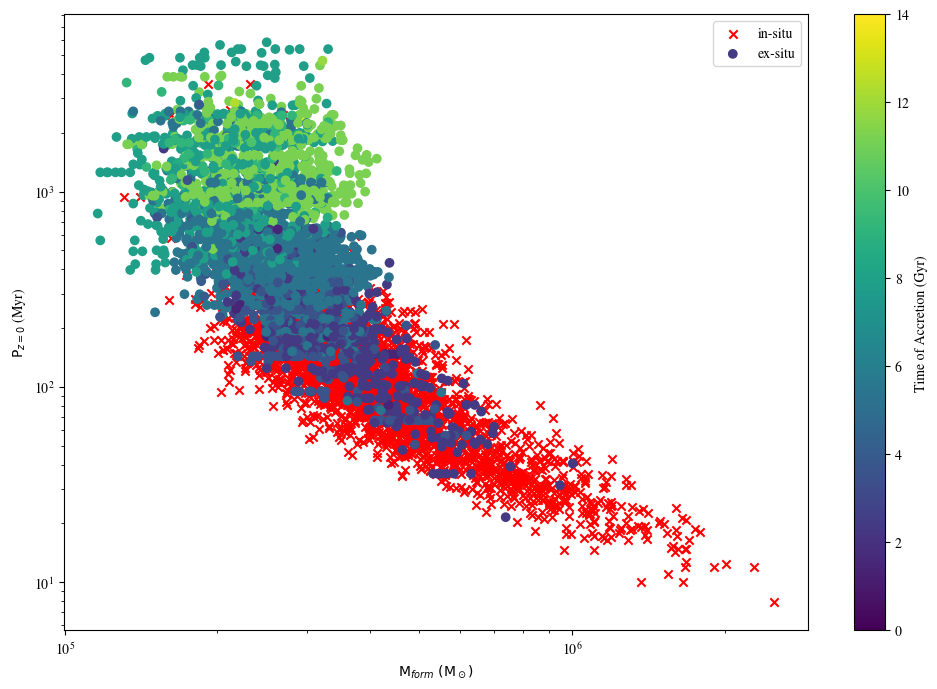

In [17]:
sim = "m12i"

mmin = 10**4.5
mmax = 10**5.0

# agmin = 11.5
# agmax = 12.0

agmin = 0
agmax = 14.0

testx_in = np.array([])
testx_ex = np.array([])

testy_in = np.array([])
testy_ex = np.array([])

testc_ex = np.array([])

testz_in = np.array([])
testz_ex = np.array([])

for it_id in sim_dict[sim].keys():
    smsk = sim_dict[sim][it_id]["s_tz0"]
    mmsk = (mmin <= sim_dict[sim][it_id]["m_tz0"]) & (sim_dict[sim][it_id]["m_tz0"] < mmax)
    amsk = sim_dict[sim][it_id]["acc"]
    agmsk = (agmin <= sim_dict[sim][it_id]["age_p"]) & (sim_dict[sim][it_id]["age_p"] < agmax)

    in_masses = sim_dict[sim][it_id]["m_tz0"][amsk & smsk & mmsk & agmsk]
    in_ages = sim_dict[sim][it_id]["age_p"][amsk & smsk & mmsk & agmsk]
    in_mfor = sim_dict[sim][it_id]["m_tfo"][amsk & smsk & mmsk & agmsk]
    # in_mfor = sim_dict[sim][it_id]["m_tz0"][amsk & smsk & mmsk & agmsk]
    in_tz0 = sim_dict[sim][it_id]["t_tz0"][amsk & smsk & mmsk & agmsk]
    in_rbir = sim_dict[sim][it_id]["r_bir"][amsk & smsk & mmsk & agmsk]

    ex_masses = sim_dict[sim][it_id]["m_tz0"][~amsk & smsk & mmsk & agmsk]
    ex_ages = sim_dict[sim][it_id]["age_p"][~amsk & smsk & mmsk & agmsk]
    ex_mfor = sim_dict[sim][it_id]["m_tfo"][~amsk & smsk & mmsk & agmsk]
    # ex_mfor = sim_dict[sim][it_id]["m_tz0"][~amsk & smsk & mmsk & agmsk]
    ex_tz0 = sim_dict[sim][it_id]["t_tz0"][~amsk & smsk & mmsk & agmsk]
    ex_rbir = sim_dict[sim][it_id]["r_bir"][~amsk & smsk & mmsk & agmsk]
    ex_tacc = sim_dict[sim][it_id]["tacc"][~amsk & smsk & mmsk & agmsk]

    testx_in = np.concatenate((testx_in, in_mfor))
    testx_ex = np.concatenate((testx_ex, ex_mfor))

    testy_in = np.concatenate((testy_in, in_tz0))
    testy_ex = np.concatenate((testy_ex, ex_tz0))

    testz_in = np.concatenate((testz_in, in_rbir))
    testz_ex = np.concatenate((testz_ex, ex_rbir))

    testc_ex = np.concatenate((testc_ex, ex_tacc))

# bins = 10 ** np.linspace(5, 6.1, 12)
# bins = 10 ** np.linspace(1, 3.3, 12)
# # bins = None

# plt.hist(test_in, bins=bins, color="r", alpha=0.2, density=True)
# plt.hist(test_ex, bins=bins, color="b", alpha=0.2, density=True)

plt.figure(figsize=(12, 8))

plt.scatter(testx_in, testy_in, c="r", marker="x", zorder=0, label="in-situ")
plt.scatter(testx_ex, testy_ex, c=testc_ex, alpha=1, label="ex-situ", vmin=0, vmax=14)
plt.colorbar(label="Time of Accretion (Gyr)")

plt.legend()

plt.xscale("log")
plt.yscale("log")

plt.xlabel(r"$\mathrm{M}_{form}\ (\mathrm{M}_\odot)$")
plt.ylabel(r"$\mathrm{P}_{z=0}$ (Myr)")

Text(0, 0.5, 'Density')

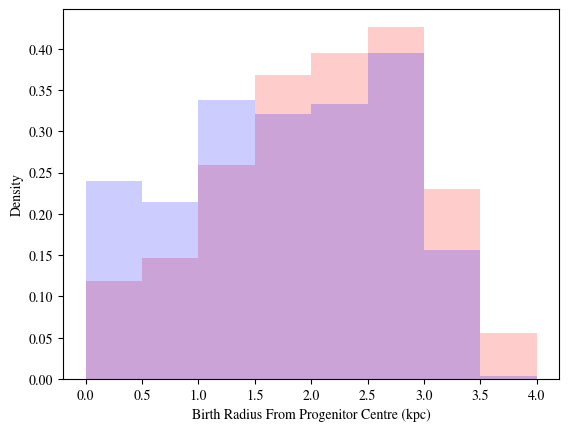

In [18]:
bins = np.linspace(0, 4, 9)

plt.hist(testz_in, bins=bins, color="r", alpha=0.2, density=True)
plt.hist(testz_ex, bins=bins, color="b", alpha=0.2, density=True)

plt.xlabel("Birth Radius From Progenitor Centre (kpc)")
plt.ylabel("Density")

In [19]:
sim = "m12i"

tfor_bins = np.arange(0, 12, 2)
mfor_bins = 10 ** np.arange(4, 7.5, 0.5)

data_arr = np.empty(shape=(len(mfor_bins) - 1, len(tfor_bins) - 1), dtype=object)
for i, j in np.ndindex(data_arr.shape):
    data_arr[i, j] = {
        "in-situ": {"x": np.array([]), "y": np.array([]), "c": np.array([])},
        "ex-situ": {"x": np.array([]), "y": np.array([]), "c": np.array([])},
    }


Text(0, 0.5, 'Mass at $z=0$ ($M_\\odot$)')

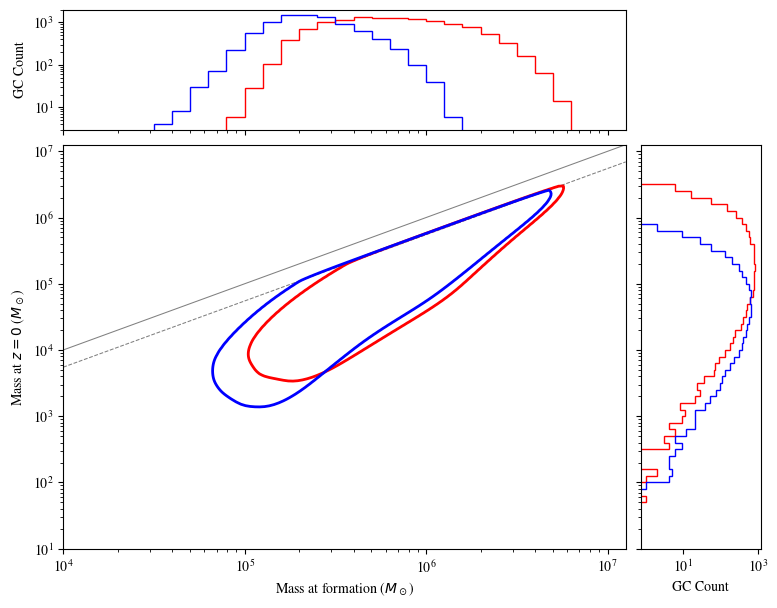

In [20]:
sim = "m12i"
cont_level = 0.95
hist_density = False


if hist_density:
    hist_label = "Density"
else:
    hist_label = "GC Count"

# Create main figure and scatter axes
fig, ax_scatter = plt.subplots(figsize=(9, 7))

# Create divider for colorbar and histograms
divider = make_axes_locatable(ax_scatter)
ax_histx = divider.append_axes("top", 1.2, pad=0.15, sharex=ax_scatter)
ax_histy = divider.append_axes("right", 1.2, pad=0.15, sharey=ax_scatter)

x_fit = np.logspace(4, 7.1)
ax_scatter.plot(x_fit, 0.55 * x_fit, c="grey", lw=0.75, ls="--")
ax_scatter.plot(x_fit, x_fit, c="grey", lw=0.75, ls="-")

logx_grid = np.linspace(2, 7.2, 200)
logy_grid = np.linspace(2, 7.2, 200)

XX, YY = np.meshgrid(logx_grid, logy_grid)
grid_positions = np.vstack([XX.ravel(), YY.ravel()])

Z_total = np.zeros(XX.shape)
n_iter = 0

hist_dict = {
    "in-situ": {"x": np.array([]), "y": np.array([])},
    "ex-situ": {"x": np.array([]), "y": np.array([])},
}

for acc in [0, 1]:
    if acc == 0:
        c = "r"
        acc_lab = "in-situ"
    elif acc == 1:
        c = "b"
        acc_lab = "ex-situ"

    for it_id in sim_dict[sim].keys():
        smsk_i = sim_dict[sim][it_id]["s_tz0"]

        if acc == 0:
            # in-situ
            amsk_i = sim_dict[sim][it_id]["acc"]
        elif acc == 1:
            # ex-situ
            amsk_i = ~sim_dict[sim][it_id]["acc"]

        msk_i = smsk_i & amsk_i
        x_i = sim_dict[sim][it_id]["m_tfo"][msk_i]
        y_i = sim_dict[sim][it_id]["m_tz0"][msk_i]

        hist_dict[acc_lab]["x"] = np.concatenate((hist_dict[acc_lab]["x"], x_i))
        hist_dict[acc_lab]["y"] = np.concatenate((hist_dict[acc_lab]["y"], y_i))

        # enforce bound
        mask = y_i <= 0.55 * x_i
        x_i = x_i[mask]
        y_i = y_i[mask]

        if len(x_i) < 20:
            continue

        logx = np.log10(x_i)
        logy = np.log10(y_i)

        kde = gaussian_kde(np.vstack([logx, logy]))
        Z = kde(grid_positions).reshape(XX.shape)

        Z_total += Z
        n_iter += 1

    Z_avg = Z_total / n_iter

    # Mask region above physical bound
    log_bound = np.log10(0.55) + XX
    Z_avg[YY > log_bound] = 0

    Z_flat = Z_avg.ravel()
    idx = np.argsort(Z_flat)[::-1]
    Z_sorted = Z_flat[idx]

    cumsum = np.cumsum(Z_sorted)
    cumsum /= cumsum[-1]

    level = Z_sorted[np.searchsorted(cumsum, cont_level)]

    ax_scatter.contour(10**XX, 10**YY, Z_avg, levels=[level], colors=c, linewidths=2)

histx_bins = np.logspace(4, 7, 31)
ax_histx.hist(hist_dict["in-situ"]["x"], bins=histx_bins, color="r", histtype="step", density=hist_density)
ax_histx.hist(hist_dict["ex-situ"]["x"], bins=histx_bins, color="b", histtype="step", density=hist_density)
ax_histx.tick_params(labelbottom=False)
ax_histx.set_ylabel(hist_label)
ax_histx.set_yscale("log")

histy_bins = np.logspace(1, 7, 61)
ax_histy.hist(
    hist_dict["in-situ"]["y"],
    bins=histy_bins,
    orientation="horizontal",
    color="r",
    histtype="step",
    density=hist_density,
)
ax_histy.hist(
    hist_dict["ex-situ"]["y"],
    bins=histy_bins,
    orientation="horizontal",
    color="b",
    histtype="step",
    density=hist_density,
)
ax_histy.tick_params(labelleft=False)
ax_histy.set_xlabel(hist_label)
ax_histy.set_xscale("log")


ax_scatter.set_xscale("log")
ax_scatter.set_yscale("log")

ax_scatter.set_xlim([10**4, 10**7.1])
ax_scatter.set_ylim([10**1, 10**7.1])

ax_scatter.set_xlabel(r"Mass at formation ($M_\odot$)")
ax_scatter.set_ylabel(r"Mass at $z=0$ ($M_\odot$)")

# TESTING
# acc = "in-situ"  # in-situ or ex-situ
# ax_scatter.scatter(hist_dict["in-situ"]["x"], hist_dict["in-situ"]["y"], c="r", s=5)

# Maybe change the above so the histograms are DN/DM (Mass function)

Text(0, 0.5, 'Mass at $z=0$ ($M_\\odot$)')

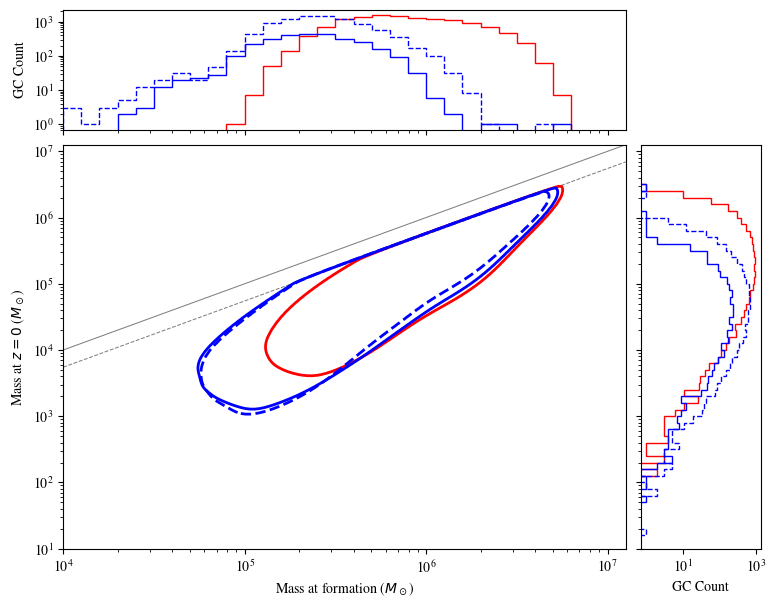

In [21]:
sim = "m12f"
cont_level = 0.95
hist_density = False
tacc_break = 7


if hist_density:
    hist_label = "Density"
else:
    hist_label = "GC Count"

# Create main figure and scatter axes
fig, ax_scatter = plt.subplots(figsize=(9, 7))

# Create divider for colorbar and histograms
divider = make_axes_locatable(ax_scatter)
ax_histx = divider.append_axes("top", 1.2, pad=0.15, sharex=ax_scatter)
ax_histy = divider.append_axes("right", 1.2, pad=0.15, sharey=ax_scatter)

x_fit = np.logspace(4, 7.1)
ax_scatter.plot(x_fit, 0.55 * x_fit, c="grey", lw=0.75, ls="--")
ax_scatter.plot(x_fit, x_fit, c="grey", lw=0.75, ls="-")

logx_grid = np.linspace(2, 7.2, 200)
logy_grid = np.linspace(2, 7.2, 200)

XX, YY = np.meshgrid(logx_grid, logy_grid)
grid_positions = np.vstack([XX.ravel(), YY.ravel()])

Z_total = np.zeros(XX.shape)
n_iter = 0

hist_dict = {
    "in-situ": {"x": np.array([]), "y": np.array([])},
    "ex-situ_e": {"x": np.array([]), "y": np.array([])},
    "ex-situ_l": {"x": np.array([]), "y": np.array([])},
}

for acc in [0, 1, 2]:
    if acc == 0:
        c = "r"
        acc_lab = "in-situ"
        ls = "-"
    elif acc == 1:
        # early accreted
        c = "b"
        acc_lab = "ex-situ_e"
        ls = "-"
    elif acc == 2:
        # late accreted
        c = "b"
        acc_lab = "ex-situ_l"
        ls = "--"

    for it_id in sim_dict[sim].keys():
        smsk_i = sim_dict[sim][it_id]["s_tz0"]
        if acc == 0:
            # in-situ
            amsk_i = sim_dict[sim][it_id]["acc"]
            tmsk_i = np.ones(len(smsk_i), dtype=bool)
        elif acc == 1:
            # early accreted
            amsk_i = ~sim_dict[sim][it_id]["acc"]
            tmsk_i = sim_dict[sim][it_id]["tacc"] <= tacc_break
        elif acc == 2:
            # late accreted
            amsk_i = ~sim_dict[sim][it_id]["acc"]
            tmsk_i = sim_dict[sim][it_id]["tacc"] > tacc_break

        msk_i = smsk_i & amsk_i & tmsk_i
        x_i = sim_dict[sim][it_id]["m_tfo"][msk_i]
        y_i = sim_dict[sim][it_id]["m_tz0"][msk_i]

        hist_dict[acc_lab]["x"] = np.concatenate((hist_dict[acc_lab]["x"], x_i))
        hist_dict[acc_lab]["y"] = np.concatenate((hist_dict[acc_lab]["y"], y_i))

        # enforce bound
        mask = y_i <= 0.55 * x_i
        x_i = x_i[mask]
        y_i = y_i[mask]

        if len(x_i) < 20:
            continue

        logx = np.log10(x_i)
        logy = np.log10(y_i)

        kde = gaussian_kde(np.vstack([logx, logy]))
        Z = kde(grid_positions).reshape(XX.shape)

        Z_total += Z
        n_iter += 1

    Z_avg = Z_total / n_iter

    # Mask region above physical bound
    log_bound = np.log10(0.55) + XX
    Z_avg[YY > log_bound] = 0

    Z_flat = Z_avg.ravel()
    idx = np.argsort(Z_flat)[::-1]
    Z_sorted = Z_flat[idx]

    cumsum = np.cumsum(Z_sorted)
    cumsum /= cumsum[-1]

    level = Z_sorted[np.searchsorted(cumsum, cont_level)]

    ax_scatter.contour(10**XX, 10**YY, Z_avg, levels=[level], colors=c, linewidths=2, linestyles=ls)

histx_bins = np.logspace(4, 7, 31)
ax_histx.hist(
    hist_dict["in-situ"]["x"],
    bins=histx_bins,
    color="r",
    histtype="step",
    density=hist_density,
    linestyle="-",
)
ax_histx.hist(
    hist_dict["ex-situ_e"]["x"],
    bins=histx_bins,
    color="b",
    histtype="step",
    density=hist_density,
    linestyle="-",
)
ax_histx.hist(
    hist_dict["ex-situ_l"]["x"],
    bins=histx_bins,
    color="b",
    histtype="step",
    density=hist_density,
    linestyle="--",
)
ax_histx.tick_params(labelbottom=False)
ax_histx.set_ylabel(hist_label)
ax_histx.set_yscale("log")

histy_bins = np.logspace(1, 7, 61)
ax_histy.hist(
    hist_dict["in-situ"]["y"],
    bins=histy_bins,
    orientation="horizontal",
    color="r",
    histtype="step",
    density=hist_density,
    linestyle="-",
)
ax_histy.hist(
    hist_dict["ex-situ_e"]["y"],
    bins=histy_bins,
    orientation="horizontal",
    color="b",
    histtype="step",
    density=hist_density,
    linestyle="-",
)
ax_histy.hist(
    hist_dict["ex-situ_l"]["y"],
    bins=histy_bins,
    orientation="horizontal",
    color="b",
    histtype="step",
    density=hist_density,
    linestyle="--",
)
ax_histy.tick_params(labelleft=False)
ax_histy.set_xlabel(hist_label)
ax_histy.set_xscale("log")


ax_scatter.set_xscale("log")
ax_scatter.set_yscale("log")

ax_scatter.set_xlim([10**4, 10**7.1])
ax_scatter.set_ylim([10**1, 10**7.1])

ax_scatter.set_xlabel(r"Mass at formation ($M_\odot$)")
ax_scatter.set_ylabel(r"Mass at $z=0$ ($M_\odot$)")

# TESTING
# acc = "in-situ"  # in-situ or ex-situ
# ax_scatter.scatter(hist_dict["in-situ"]["x"], hist_dict["in-situ"]["y"], c="r", s=5)

Could I plot a probability space, initial mass vs final mass, where the squares are coloured by probability

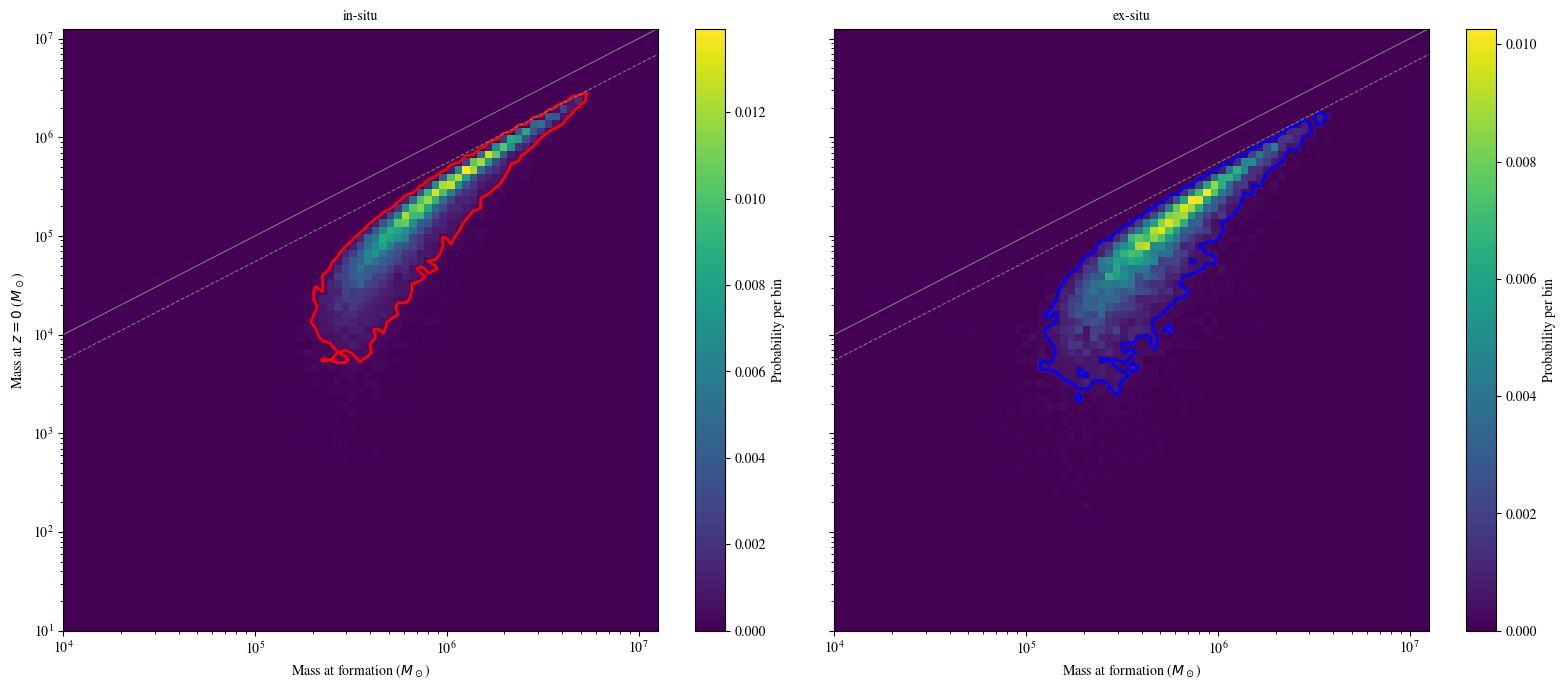

In [22]:
sim = "m12m"
cont_level = 0.95
hist_density = False

if hist_density:
    hist_label = "Density"
else:
    hist_label = "GC Count"

# --------------------------------------------------
# Collect all data first
# --------------------------------------------------

hist_dict = {
    "in-situ": {"x": np.array([]), "y": np.array([])},
    "ex-situ": {"x": np.array([]), "y": np.array([])},
}

for it_id in sim_dict[sim].keys():
    smsk_i = sim_dict[sim][it_id]["s_tz0"]

    for acc_lab, acc_mask in zip(
        ["in-situ", "ex-situ"], [sim_dict[sim][it_id]["acc"], ~sim_dict[sim][it_id]["acc"]]
    ):
        msk_i = smsk_i & acc_mask

        x_i = sim_dict[sim][it_id]["m_tfo"][msk_i]
        y_i = sim_dict[sim][it_id]["m_tz0"][msk_i]

        hist_dict[acc_lab]["x"] = np.concatenate((hist_dict[acc_lab]["x"], x_i))
        hist_dict[acc_lab]["y"] = np.concatenate((hist_dict[acc_lab]["y"], y_i))

# --------------------------------------------------
# Figure with two panels
# --------------------------------------------------

fig, axs = plt.subplots(1, 2, figsize=(16, 7), sharex=True, sharey=True)

xbins = np.linspace(4, 7.1, 80)
ybins = np.linspace(1, 7.1, 80)

for ax, acc_lab, color in zip(axs, ["in-situ", "ex-situ"], ["r", "b"]):
    x = hist_dict[acc_lab]["x"]
    y = hist_dict[acc_lab]["y"]

    # Enforce physical bound
    mask = y <= 0.55 * x
    x = x[mask]
    y = y[mask]

    logx = np.log10(x)
    logy = np.log10(y)

    # 2D histogram
    H, xedges, yedges = np.histogram2d(
        logx,
        logy,
        bins=[xbins, ybins],
    )

    # Convert to probability
    P = H / np.sum(H)

    # Compute bin centers
    xcent = 0.5 * (xedges[:-1] + xedges[1:])
    ycent = 0.5 * (yedges[:-1] + yedges[1:])

    XXc, YYc = np.meshgrid(xcent, ycent)

    # Physical bound in log space
    log_bound = np.log10(0.55) + XXc

    P_masked = P.T.copy()
    P_masked[YYc > log_bound] = 0

    # Plot probability map
    X_plot, Y_plot = np.meshgrid(10**xedges, 10**yedges)

    pcm = ax.pcolormesh(X_plot, Y_plot, P_masked, shading="auto", cmap="viridis")

    # --------------------------------------------------
    # 95% highest-probability contour
    # --------------------------------------------------

    # Flatten probability grid
    P_flat = P_masked.ravel()
    idx = np.argsort(P_flat)[::-1]
    P_sorted = P_flat[idx]

    cumsum = np.cumsum(P_sorted)
    cumsum /= cumsum[-1]

    level = P_sorted[np.searchsorted(cumsum, cont_level)]

    # Use BIN CENTERS for contour
    Xc_plot, Yc_plot = np.meshgrid(10**xcent, 10**ycent)

    ax.contour(Xc_plot, Yc_plot, P_masked, levels=[level], colors=color, linewidths=2)

    # Reference lines
    x_fit = np.logspace(4, 7.1)
    ax.plot(x_fit, 0.55 * x_fit, c="grey", lw=0.75, ls="--")
    ax.plot(x_fit, x_fit, c="grey", lw=0.75)

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlim([10**4, 10**7.1])
    ax.set_ylim([10**1, 10**7.1])

    ax.set_title(acc_lab)

    # Add colorbar per panel
    cbar = fig.colorbar(pcm, ax=ax)
    cbar.set_label("Probability per bin")

# Labels
axs[0].set_ylabel(r"Mass at $z=0$ ($M_\odot$)")
for ax in axs:
    ax.set_xlabel(r"Mass at formation ($M_\odot$)")

plt.tight_layout()
plt.show()